# Setup

In [1]:
!pip install codecarbon networkx pandas matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\im\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
# codecarbon ใช้สำหรับวัดการใช้พลังงาน
from codecarbon import EmissionsTracker
# tracemalloc ใช้สำหรับวัดการใช้หน่วยความจำ
import tracemalloc
# time ใช้สำหรับวัดเวลาในการทำงาน
import time
# networkx ใช้สำหรับสร้างและจัดการกราฟ
import networkx as nx
# pickle และ os ใช้สำหรับบันทึกผลลัพธ์
import pickle
import os
# math และ random ใช้สำหรับคำนวณและสุ่มค่า
import math
import random
# pandas ใช้สำหรับจัดการข้อมูลในรูปแบบตาราง
import pandas as pd
# matplotlib และ seaborn ใช้สำหรับการสร้างกราฟและการวิเคราะห์ข้อมูล
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
SEED = 67
NUM_PAIRS = 50   # จำนวนคู่ Source-Destination ที่ต้องการสุ่มทดสอบ
SAVE_PATH = "./results"
# กำหนด Config ของกราฟที่ต้องการ (Nodes, Edges)
GRAPH_CONFIGS = [
    (1000, 5000),
    (5000, 25000),
    (10000, 50000),
    (50000, 250000)
]

# Graph Generation

In [4]:
# ฟังก์ชันสร้างกราฟ
def create_geometry_based_graph(num_nodes, num_edges, seed):
    # สร้างกราฟเปล่า
    G = nx.gnm_random_graph(num_nodes, num_edges, seed=seed)
    
    # กำหนดพิกัด (Positions)
    random.seed(seed)
    pos = {i: (random.uniform(0, 100), random.uniform(0, 100)) for i in G.nodes()}
    nx.set_node_attributes(G, pos, 'pos')
    
    # คำนวณ Weight จากระยะทางจริง
    for u, v in G.edges():
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        dist = math.sqrt((x1 - x2)**2 + (y1 - y2)**2)
        G.edges[u, v]['weight'] = round(dist, 2)
        
    return G

# ส่วนจัดการไฟล์ (Load/Create Loop)
experiment_graphs = {}  # ตัวแปร Dictionary สำหรับเก็บกราฟทั้งหมดไว้ใช้งาน

print("Checking graph files...")

for nodes, edges in GRAPH_CONFIGS:
    filename = f"test_graph_{nodes}.gml"
    
    if os.path.exists(filename):
        # ถ้ามีไฟล์แล้ว Load ขึ้นมาเก็บใน Dict
        print(f"Loading {filename}...")
        # destringizer=int เพื่อให้ชื่อโหนดเป็น int เหมือนตอนสร้าง
        G = nx.read_gml(filename, destringizer=int) 
    else:
        # ถ้าไม่มี ให้สร้างใหม่ด้วยฟังก์ชันที่มีพิกัด+น้ำหนัก แล้ว Save
        print(f"Generating new graph: {nodes} nodes...")
        G = create_geometry_based_graph(nodes, edges, SEED)
        nx.write_gml(G, filename)
        print(f"Saved {filename}")

    # เก็บกราฟลงใน Dictionary โดยใช้จำนวนโหนดเป็น Key
    experiment_graphs[nodes] = G

print("\nAll graphs are ready in 'experiment_graphs' dictionary.")

Checking graph files...
Loading test_graph_1000.gml...
Loading test_graph_5000.gml...
Loading test_graph_10000.gml...
Loading test_graph_50000.gml...

All graphs are ready in 'experiment_graphs' dictionary.


# Algorithm

In [ ]:
# Helper Functions (สำหรับ A* Heuristic)

def get_heuristic(algorithm_mode="euclidean"):
    """
    คืนค่าฟังก์ชัน Heuristic ตามโหมดที่เลือก (Euclidean หรือ Manhattan)
    สำหรับใช้ใน A* Algorithm
    """
    def euclidean_dist(u, v):
        # ดึงพิกัด (x, y) จากโหนด
        # หมายเหตุ: กราฟต้องมี attribute 'pos' เก็บค่า (x, y)
        x1, y1 = G_global.nodes[u]['pos'] 
        x2, y2 = G_global.nodes[v]['pos']
        return math.sqrt((x1 - x2)**2 + (y1 - y2)**2)

    def manhattan_dist(u, v):
        x1, y1 = G_global.nodes[u]['pos']
        x2, y2 = G_global.nodes[v]['pos']
        return abs(x1 - x2) + abs(y1 - y2)

    if algorithm_mode == "manhattan":
        return manhattan_dist
    return euclidean_dist

# ตัวแปร Global เพื่อให้ Heuristic เรียกใช้กราฟได้ (เนื่องจาก nx.astar_path รับแค่ func(u, v))
G_global = None 

# Algorithm Functions (Core)

def run_dijkstra(G, source, target):
    """
    Dijkstra Algorithm: เหมาะสำหรับกราฟที่ไม่มีน้ำหนักติดลบ
    คืนค่า: เส้นทาง (list of nodes)
    """
    try:
        # ใช้ implementation มาตรฐานของ NetworkX ซึ่งเร็วและแม่นยำ
        path = nx.dijkstra_path(G, source=source, target=target, weight='weight')
        return path
    except nx.NetworkXNoPath:
        return None

def run_bellman_ford(G, source, target):
    """
    Bellman-Ford Algorithm: รองรับน้ำหนักติดลบ แต่ทำงานช้ากว่า (Complexity สูง)
    คืนค่า: เส้นทาง (list of nodes)
    """
    try:
        path = nx.bellman_ford_path(G, source=source, target=target, weight='weight')
        return path
    except nx.NetworkXNoPath:
        return None
    except nx.NetworkXUnbounded:
        print("Graph contains a negative cycle!")
        return None

def run_astar(G, source, target, heuristic_mode="euclidean"):
    """
    A* Algorithm: ค้นหาโดยใช้ Heuristic Function ช่วยนำทาง
    คืนค่า: เส้นทาง (list of nodes)
    """
    global G_global
    G_global = G  # set global graph for heuristic function access
    
    h_func = get_heuristic(heuristic_mode)
    
    try:
        path = nx.astar_path(G, source=source, target=target, heuristic=h_func, weight='weight')
        return path
    except nx.NetworkXNoPath:
        return None

In [6]:
def execute_experiment(algo_func, G, source, target, algo_name, run_id, **kwargs):
    """
    รันอัลกอริทึม 1 ครั้ง พร้อมวัดผล Time, Memory, Energy
    """
    # เตรียมตัวแปรสำหรับ CodeCarbon
    # measure_power_secs=0.1 คือให้อ่านค่าไฟทุก 0.1 วินาที
    tracker = EmissionsTracker(
        project_name=f"{algo_name}_Experiment",
        output_dir="./raw_emissions",  # แยกไฟล์ log ของ codecarbon ไว้ต่างหาก
        measure_power_secs=0.1,
        save_to_file=True,             # บันทึก log ดิบเผื่อไว้ตรวจสอบ
        log_level='error'              # เหลือ log ไว้แค่ error
    )
    
    # เริ่มจับ Memory
    tracemalloc.start()
    
    # เริ่มจับ Energy
    tracker.start()
    
    # เริ่มจับ Time
    start_time = time.time()
    
    try:
        # รันอัลกอริทึม
        if algo_name == "A_Star":
            path = algo_func(G, source, target, **kwargs)
        else:
            path = algo_func(G, source, target)
        
    except Exception as e:
        print(f"Error in {algo_name}: {e}")
        path = None
        
    finally:
        # หยุดจับ Time
        end_time = time.time()
        
        # หยุดจับ Energy (และดึงค่า)
        tracker.stop()
        
        # หยุดจับ Memory
        current_mem, peak_mem = tracemalloc.get_traced_memory()
        tracemalloc.stop()

    # การดึงค่าพลังงาน
    # tracker.final_emissions_data จะเก็บข้อมูลสรุปทั้งหมด
    # แปลง kWh to Joules (1 kWh = 3,600,000 Joules)
    energy_kwh = tracker.final_emissions_data.energy_consumed
    cpu_energy_kwh = tracker.final_emissions_data.cpu_energy
    
    total_joules = energy_kwh * 3_600_000 if energy_kwh is not None else 0
    cpu_joules = cpu_energy_kwh * 3_600_000 if cpu_energy_kwh is not None else 0

    # คืนค่าเป็น Dictionary เพื่อเก็บเข้าตาราง
    return {
        "run_id": run_id,
        "algorithm": algo_name,
        "nodes": len(G.nodes()),
        "edges": len(G.edges()),
        "time_sec": end_time - start_time,
        "memory_peak_mb": peak_mem / (1024 * 1024), # Convert Bytes -> MB
        "energy_joules": total_joules,
        "cpu_energy_joules": cpu_joules,
        "path_found": path is not None,
        "path_length": len(path) if path else 0
    }

In [ ]:
import pandas as pd
import random

results_data = [] # ลิสต์สำหรับเก็บผลลัพธ์ทั้งหมด

print(f"Starting Experiments... (Test Pairs per graph: {NUM_PAIRS})")

for num_nodes, G in experiment_graphs.items():
    print(f"\n--- Testing on Graph with {num_nodes} Nodes ---")
    
    # 1. กำหนด Seed ของแต่ละขนาดกราฟ 
    # (บวก num_nodes เข้าไปเพื่อให้กราฟแต่ละขนาดสุ่มได้คู่ที่ไม่ซ้ำแพทเทิร์นกัน)
    random.seed(SEED + num_nodes)
    
    # 2. สร้างรายการคู่ทดสอบ 50 คู่ที่ไม่ซ้ำกัน (ตัวต้นทางกับปลายทางต้องไม่เป็นโหนดเดียวกัน)
    node_list = list(G.nodes())
    test_pairs = []
    for _ in range(NUM_PAIRS):
        # random.sample จะสุ่มหยิบ 2 โหนดที่ไม่ซ้ำกันออกมา
        u, v = random.sample(node_list, 2)
        test_pairs.append((u, v))
        
    # 3. เริ่มรันการทดลองตามคู่ที่สุ่มได้
    for pair_id, (source_node, target_node) in enumerate(test_pairs):
        
        # ปริ้นอัปเดตสถานะทุกๆ 10 รอบ
        if (pair_id + 1) % 10 == 0 or pair_id == 0:
            print(f"  Testing Pair {pair_id+1}/{NUM_PAIRS} (S:{source_node} -> T:{target_node})...")
        
        # 1. Test Dijkstra
        res_dijkstra = execute_experiment(
            run_dijkstra, G, source_node, target_node, 
            "Dijkstra", pair_id
        )
        # เพิ่มข้อมูลโหนดต้นทาง-ปลายทางเข้าไปใน Dict
        res_dijkstra["source_node"] = source_node
        res_dijkstra["target_node"] = target_node
        results_data.append(res_dijkstra)
        
        # 2. Test Bellman-Ford
        res_bellman = execute_experiment(
                run_bellman_ford, G, source_node, target_node, 
                "Bellman-Ford", pair_id
            )
        res_bellman["source_node"] = source_node
        res_bellman["target_node"] = target_node
        results_data.append(res_bellman)
            
        # 3. Test A* (Euclidean)
        res_astar = execute_experiment(
            run_astar, G, source_node, target_node, 
            "A_Star", pair_id, heuristic_mode="euclidean"
        )
        res_astar["source_node"] = source_node
        res_astar["target_node"] = target_node
        results_data.append(res_astar)

# 4. Save Data

# แปลงเป็น DataFrame
df_results = pd.DataFrame(results_data)

# จัดเรียงคอลัมน์ให้อ่านง่ายขึ้น (เอาโหนดไว้ด้านหน้าๆ)
cols = ['run_id', 'algorithm', 'nodes', 'edges', 'source_node', 'target_node', 
        'time_sec', 'memory_peak_mb', 'energy_joules', 'cpu_energy_joules', 'path_found', 'path_length']
# ถ้ามีคอลัมน์ไหนขาดหายไปใน execute_experiment มันจะไม่ error แต่จะจัดเรียงเท่าที่มี
df_results = df_results[[c for c in cols if c in df_results.columns]]

# ดูตัวอย่างข้อมูล
print("\nExperiment Complete!")
print(df_results.head(10)) # ปริ้นดู 10 แถวแรก

# บันทึกเป็น CSV เพื่อนำไปทำ Visualization ต่อ
df_results.to_csv("final_experiment_results.csv", index=False)
print("Saved results to 'final_experiment_results.csv'")

Starting Experiments... (Test Pairs per graph: 50)

--- Testing on Graph with 1000 Nodes ---
  Testing Pair 1/50 (S:255 -> T:149)...
  Testing Pair 10/50 (S:175 -> T:755)...
  Testing Pair 20/50 (S:781 -> T:210)...
  Testing Pair 30/50 (S:426 -> T:821)...
  Testing Pair 40/50 (S:722 -> T:202)...
  Testing Pair 50/50 (S:732 -> T:253)...

--- Testing on Graph with 5000 Nodes ---
  Testing Pair 1/50 (S:1757 -> T:4338)...
  Testing Pair 10/50 (S:1987 -> T:4103)...
  Testing Pair 20/50 (S:1722 -> T:3314)...
  Testing Pair 30/50 (S:736 -> T:3669)...
  Testing Pair 40/50 (S:3281 -> T:3907)...
  Testing Pair 50/50 (S:1746 -> T:1440)...

--- Testing on Graph with 10000 Nodes ---
  Testing Pair 1/50 (S:5898 -> T:6294)...
  Testing Pair 10/50 (S:1154 -> T:8072)...
  Testing Pair 20/50 (S:7718 -> T:2772)...
  Testing Pair 30/50 (S:8914 -> T:1071)...
  Testing Pair 40/50 (S:1935 -> T:3271)...
  Testing Pair 50/50 (S:1403 -> T:1173)...

--- Testing on Graph with 50000 Nodes ---
  Testing Pair 1/50 (

# Result

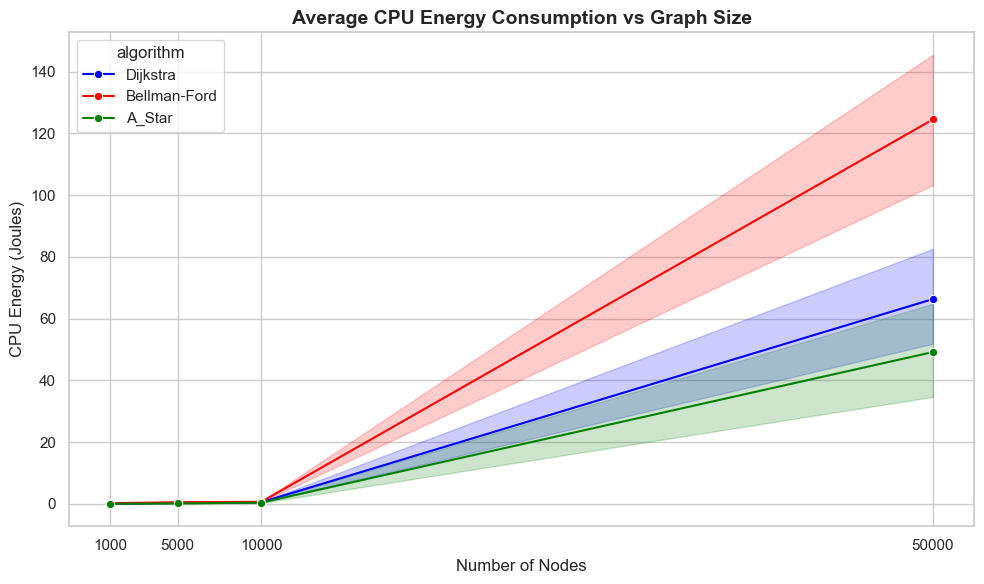

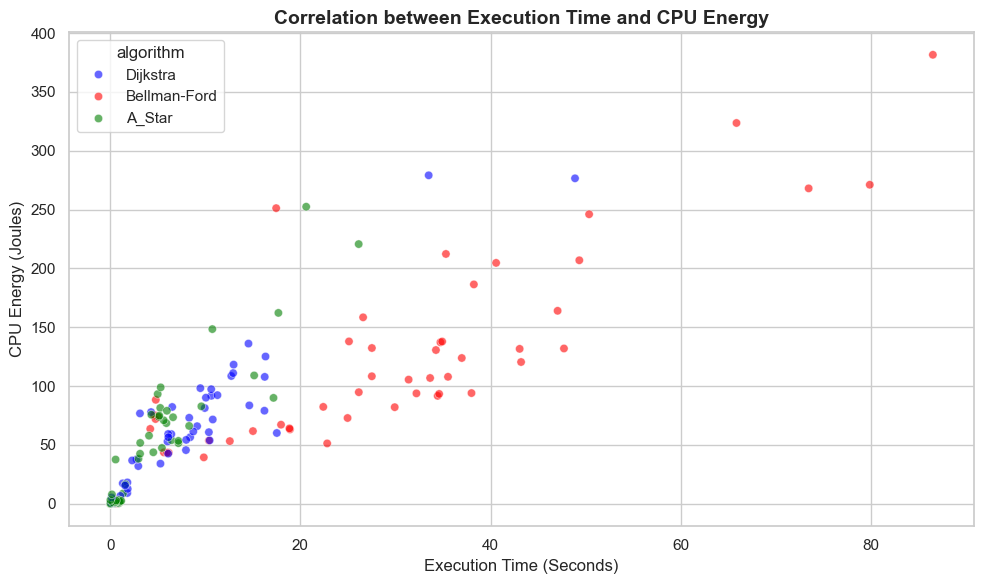

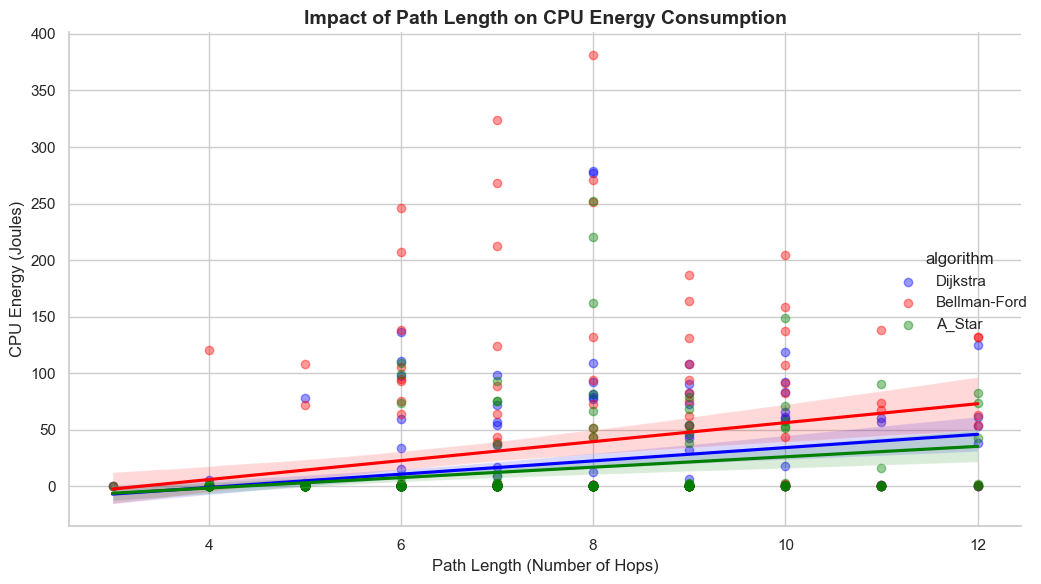

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# โหลดข้อมูล
df = pd.read_csv("final_experiment_results.csv")

# ตั้งค่าสไตล์ของกราฟให้ดูเป็นงานวิจัย
sns.set_theme(style="whitegrid")
palette = {"Dijkstra": "blue", "Bellman-Ford": "red", "A_Star": "green"}

# Figure 1: Scalability (Nodes vs CPU Energy)
plt.figure(figsize=(10, 6))
# ใช้ Lineplot จะโชว์เส้นค่าเฉลี่ย (Mean) พร้อมแถบสีอ่อนๆ แสดงความแปรปรวน (Confidence Interval)
sns.lineplot(data=df, x="nodes", y="cpu_energy_joules", hue="algorithm", marker="o", palette=palette)
plt.title("Average CPU Energy Consumption vs Graph Size", fontsize=14, fontweight="bold")
plt.xlabel("Number of Nodes", fontsize=12)
plt.ylabel("CPU Energy (Joules)", fontsize=12)
plt.xticks(df['nodes'].unique()) # ให้แกน x โชว์เลข node ตรงๆ
plt.tight_layout()
plt.savefig("plot_energy_vs_nodes.png", dpi=300)
plt.show()

# Figure 2: Time vs Energy Correlation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="time_sec", y="cpu_energy_joules", hue="algorithm", alpha=0.6, palette=palette)
plt.title("Correlation between Execution Time and CPU Energy", fontsize=14, fontweight="bold")
plt.xlabel("Execution Time (Seconds)", fontsize=12)
plt.ylabel("CPU Energy (Joules)", fontsize=12)
plt.tight_layout()
plt.savefig("plot_time_vs_energy.png", dpi=300)
plt.show()

# Figure 3: Path Length Impact (Scatter with Trendline)
# กรองข้อมูลเฉพาะตอนที่หาทางเจอ (path_found == True) เพื่อความแม่นยำ
df_success = df[df["path_found"] == True]

# lmplot จะสร้าง Scatter plot พร้อมลากเส้นแนวโน้ม (Regression Line) ให้เลย
g = sns.lmplot(
    data=df_success, 
    x="path_length", 
    y="cpu_energy_joules", 
    hue="algorithm", 
    palette=palette,
    height=6, aspect=1.5, 
    scatter_kws={'alpha':0.4}
)
plt.title("Impact of Path Length on CPU Energy Consumption", fontsize=14, fontweight="bold")
plt.xlabel("Path Length (Number of Hops)", fontsize=12)
plt.ylabel("CPU Energy (Joules)", fontsize=12)
plt.tight_layout()
plt.savefig("plot_pathlength_vs_energy.png", dpi=300)
plt.show()

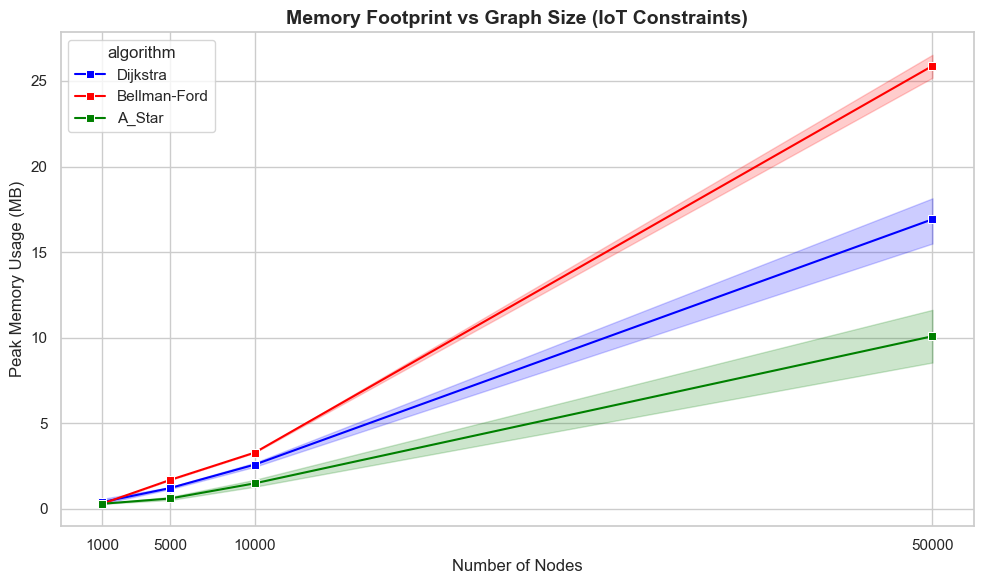

C:\Users\im\AppData\Local\Temp\ipykernel_8940\3388164504.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_50k, x="algorithm", y="cpu_energy_joules", palette=palette)


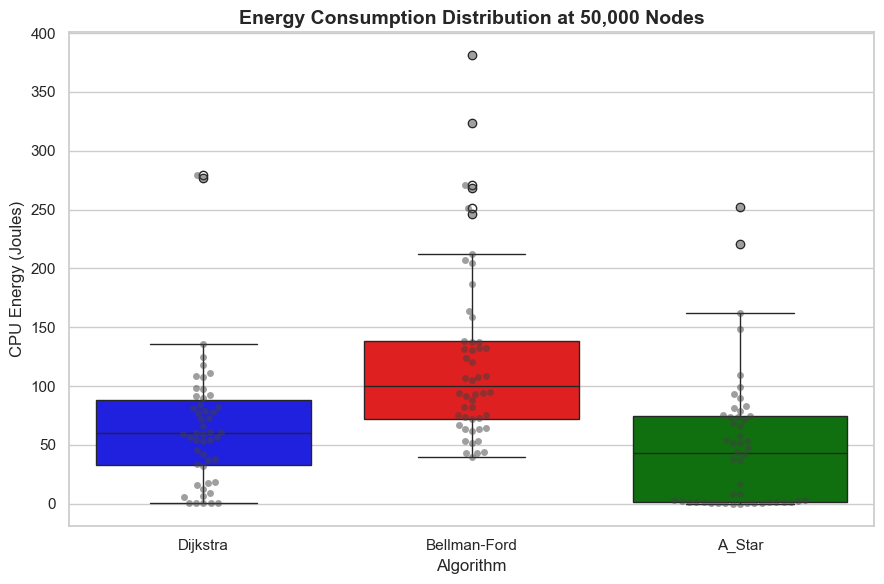

In [ ]:
# โหลดข้อมูล (สมมติว่าตัวแปร df มีอยู่แล้วจากโค้ดชุดก่อน)
df = pd.read_csv("final_experiment_results.csv")
sns.set_theme(style="whitegrid")
palette = {"Dijkstra": "blue", "Bellman-Ford": "red", "A_Star": "green"}

# Figure 4: Memory Footprint (Peak Memory vs Nodes)
plt.figure(figsize=(10, 6))
# ใช้ Lineplot เพื่อดูแนวโน้มการเติบโตของ RAM
sns.lineplot(data=df, x="nodes", y="memory_peak_mb", hue="algorithm", marker="s", palette=palette)
plt.title("Memory Footprint vs Graph Size (IoT Constraints)", fontsize=14, fontweight="bold")
plt.xlabel("Number of Nodes", fontsize=12)
plt.ylabel("Peak Memory Usage (MB)", fontsize=12)
plt.xticks(df['nodes'].unique())
plt.tight_layout()
plt.savefig("plot_memory_vs_nodes.png", dpi=300)
plt.show()

# Figure 5: Energy Distribution Boxplot (Only 50k Nodes)
# กรองเอาเฉพาะข้อมูลที่รันบนกราฟ 50,000 โหนด
df_50k = df[df['nodes'] == 50000]

plt.figure(figsize=(9, 6))
# ใช้ Boxplot โชว์การกระจายตัว ค่าเฉลี่ย และ Outliers
sns.boxplot(data=df_50k, x="algorithm", y="cpu_energy_joules", palette=palette)
plt.title("Energy Consumption Distribution at 50,000 Nodes", fontsize=14, fontweight="bold")
plt.xlabel("Algorithm", fontsize=12)
plt.ylabel("CPU Energy (Joules)", fontsize=12)

# ใส่จุดเล็กๆ (Swarmplot) ทับลงไปให้เห็นจำนวนรอบที่ทดสอบจริง 
# (ถ้าข้อมูล 100 จุดเยอะไป อาจจะปิดบรรทัดนี้ได้ครับ)
sns.swarmplot(data=df_50k, x="algorithm", y="cpu_energy_joules", color=".25", alpha=0.5)

plt.tight_layout()
plt.savefig("plot_boxplot_50k.png", dpi=300)
plt.show()